In [1]:
!pip -q install pandas numpy matplotlib seaborn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
data = [
    ["Dataset_A", "fMRI", "virtual_navigation", 60, True, True],
    ["Dataset_B", "fMRI", "mental_rotation", 45, True, False],
    ["Dataset_C", "EEG-fMRI", "self_motion", 32, True, True],
    ["Dataset_D", "fMRI", "landmark_memory", 50, False, True],
    ["Dataset_E", "MEG", "path_integration", 28, True, False],
    ["Dataset_F", "fMRI", "egocentric_vs_allocentric", 40, True, True],
]

df = pd.DataFrame(
    data,
    columns=[
        "dataset",
        "modality",
        "task",
        "n_subjects",
        "network_usable",
        "behavior_available"
    ]
)

df

,dataset,modality,task,n_subjects,network_usable,behavior_available
0,Dataset_A,fMRI,virtual_navigation,60,True,True
1,Dataset_B,fMRI,mental_rotation,45,True,False
2,Dataset_C,EEG-fMRI,self_motion,32,True,True
3,Dataset_D,fMRI,landmark_memory,50,False,True
4,Dataset_E,MEG,path_integration,28,True,False
5,Dataset_F,fMRI,egocentric_vs_allocentric,40,True,True


In [4]:
summary = (
    df.groupby("task")["n_subjects"]
    .sum()
    .reset_index()
    .sort_values("n_subjects", ascending=False)
)

summary

,task,n_subjects
5,virtual_navigation,60
1,landmark_memory,50
2,mental_rotation,45
0,egocentric_vs_allocentric,40
4,self_motion,32
3,path_integration,28


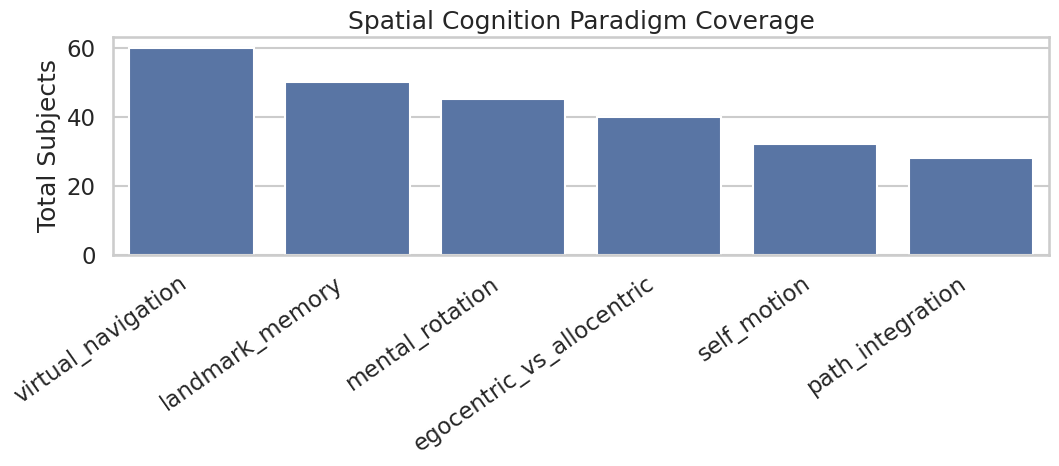

In [5]:
plt.figure(figsize=(11,5))

sns.barplot(
    data=summary,
    x="task",
    y="n_subjects"
)

plt.xticks(rotation=35, ha="right")
plt.xlabel("")
plt.ylabel("Total Subjects")
plt.title("Spatial Cognition Paradigm Coverage")
plt.tight_layout()
plt.savefig("figures/01_task_landscape.png", dpi=300)
plt.show()

In [6]:
readiness = df[
    (df["network_usable"] == True) &
    (df["behavior_available"] == True)
]

readiness.to_csv("outputs/01_spatial_dataset_readiness.csv", index=False)
df.to_csv("outputs/01_full_dataset_landscape.csv", index=False)

readiness

,dataset,modality,task,n_subjects,network_usable,behavior_available
0,Dataset_A,fMRI,virtual_navigation,60,True,True
2,Dataset_C,EEG-fMRI,self_motion,32,True,True
5,Dataset_F,fMRI,egocentric_vs_allocentric,40,True,True
